# 피부 분석 AI 프로젝트 EDA

이 노트북은 프로젝트의 전체 구조와 핵심 로직을 한눈에 파악할 수 있도록 작성되었습니다.

## 목차
1. 프로젝트 구조
2. 데이터셋 탐색
3. 모델 아키텍처
4. 추론 파이프라인
5. 점수 산정 로직
6. 성능 벤치마크
7. PyTorch vs ONNX 비교

In [40]:
import os
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 프로젝트 루트 설정
PROJECT_ROOT = Path(os.getcwd()).parent if os.path.basename(os.getcwd()) == 'docs' else Path(os.getcwd())
print(f"Project Root: {PROJECT_ROOT}")

Project Root: /home/j-i14a704/work/seunghun/S14P11A704/ai/skin-analysis/NIA


---
## 1. 프로젝트 구조

In [41]:
structure = """
NIA/
├── app/                           # Production Service
│   ├── main.py                    # FastAPI Entrypoint
│   ├── analysis/
│   │   └── service_inference.py   # ONNX Inference (Core)
│   └── resources/
│       ├── calibration_rules.json # Landmark Crop Rules
│       └── face_landmarker.task   # MediaPipe Model
│
├── core/                          # Training Code
│   ├── main.py                    # Training Entrypoint
│   ├── model.py                   # Model Definition (timm CoAtNet)
│   └── data_loader.py             # Data Loader
│
├── scripts/                       # Utilities
│   ├── convert_to_onnx.py         # PyTorch -> ONNX
│   ├── calculate_thresholds.py    # Score Thresholds
│   └── preprocess_dataset_mediapipe.py
│
├── checkpoint/                    # Trained Models
│   ├── regression/1st_robust/     # Regression (moisture, pore, pigmentation, wrinkle_Ra)
│   └── class/1st_robust/          # Classification (wrinkle, sagging)
│
└── docs/                          # Documentation
"""
print(structure)


NIA/
├── app/                           # Production Service
│   ├── main.py                    # FastAPI Entrypoint
│   ├── analysis/
│   │   └── service_inference.py   # ONNX Inference (Core)
│   └── resources/
│       ├── calibration_rules.json # Landmark Crop Rules
│       └── face_landmarker.task   # MediaPipe Model
│
├── core/                          # Training Code
│   ├── main.py                    # Training Entrypoint
│   ├── model.py                   # Model Definition (timm CoAtNet)
│   └── data_loader.py             # Data Loader
│
├── scripts/                       # Utilities
│   ├── convert_to_onnx.py         # PyTorch -> ONNX
│   ├── calculate_thresholds.py    # Score Thresholds
│   └── preprocess_dataset_mediapipe.py
│
├── checkpoint/                    # Trained Models
│   ├── regression/1st_robust/     # Regression (moisture, pore, pigmentation, wrinkle_Ra)
│   └── class/1st_robust/          # Classification (wrinkle, sagging)
│
└── docs/                         

---
## 2. 데이터셋 탐색

In [42]:
label_dir = PROJECT_ROOT / "dataset" / "label"

if label_dir.exists():
    equ_counts = {}
    for equ in os.listdir(label_dir):
        equ_path = label_dir / equ
        if equ_path.is_dir():
            count = sum(1 for _ in equ_path.rglob("*.json"))
            equ_counts[equ] = count
    
    print("Label file counts by equipment:")
    for equ, count in equ_counts.items():
        print(f"  {equ}: {count:,}")
else:
    print("Dataset path not found.")

Label file counts by equipment:
  02: 26,055
  03: 26,055
  01: 60,795


In [43]:
# Sample label JSON
sample_json = None
if label_dir.exists():
    for json_file in label_dir.rglob("*.json"):
        with open(json_file, "r", encoding="utf-8") as f:
            sample_json = json.load(f)
        break

if sample_json:
    print("Label JSON structure:")
    print(json.dumps(sample_json, indent=2, ensure_ascii=False)[:1000])

Label JSON structure:
{
  "info": {
    "filename": "0898_02_R.jpg",
    "id": "0898",
    "gender": "F",
    "age": 50,
    "date": "2023-10-05",
    "skin_type": 1,
    "sensitive": 0
  },
  "images": {
    "device": 1,
    "width": 2448,
    "height": 3264,
    "angle": 8,
    "facepart": 6,
    "bbox": [
      1875,
      1411,
      1981,
      1860
    ]
  },
  "annotations": {
    "r_cheek_pore": 2,
    "r_cheek_pigmentation": 2
  },
  "equipment": {
    "r_cheek_moisture": 65.0,
    "r_cheek_elasticity_R0": 0.154,
    "r_cheek_elasticity_R1": 0.085,
    "r_cheek_elasticity_R2": 0.448,
    "r_cheek_elasticity_R3": 0.183,
    "r_cheek_elasticity_R4": 0.122,
    "r_cheek_elasticity_R5": 0.488,
    "r_cheek_elasticity_R6": 0.791,
    "r_cheek_elasticity_R7": 0.273,
    "r_cheek_elasticity_R8": 0.069,
    "r_cheek_elasticity_R9": 0.029,
    "r_cheek_elasticity_Q0": 30.8,
    "r_cheek_elasticity_Q1": 0.405,
    "r_cheek_elasticity_Q2": 0.337,
    "r_cheek_elasticity_Q3": 0.069,
    "

---
## 3. 모델 아키텍처

In [44]:
from IPython.display import Markdown, display

model_info = """
### Model: CoAtNet-2 (timm)

- Architecture: Convolutional + Attention Hybrid
- Input Size: 224 x 224 x 3
- Backbone: coatnet_2_rw_224 (ImageNet pretrained)

### Trained Models

| Type | Model Name | Output Range | Description |
|:---|:---|:---|:---|
| Regression | reg_moisture | 0~100 | Skin moisture level |
| Regression | reg_pore | 0~2600 | Pore area |
| Regression | reg_pigmentation | 0~350 | Pigmentation level |
| Regression | reg_wrinkle_eye | 0~50 | Eye wrinkle (Ra value) |
| Classification | class_wrinkle | 0~6 | Wrinkle grade |
| Classification | class_sagging | 0~5 | Sagging grade |
"""
display(Markdown(model_info))


### Model: CoAtNet-2 (timm)

- Architecture: Convolutional + Attention Hybrid
- Input Size: 224 x 224 x 3
- Backbone: coatnet_2_rw_224 (ImageNet pretrained)

### Trained Models

| Type | Model Name | Output Range | Description |
|:---|:---|:---|:---|
| Regression | reg_moisture | 0~100 | Skin moisture level |
| Regression | reg_pore | 0~2600 | Pore area |
| Regression | reg_pigmentation | 0~350 | Pigmentation level |
| Regression | reg_wrinkle_eye | 0~50 | Eye wrinkle (Ra value) |
| Classification | class_wrinkle | 0~6 | Wrinkle grade |
| Classification | class_sagging | 0~5 | Sagging grade |


In [45]:
# Checkpoint file sizes
checkpoint_dir = PROJECT_ROOT / "checkpoint"

if checkpoint_dir.exists():
    print("ONNX Model file sizes (1st_robust):")
    for onnx_file in checkpoint_dir.rglob("1st_robust/**/model.onnx.data"):
        size_mb = onnx_file.stat().st_size / (1024 * 1024)
        relative_path = onnx_file.relative_to(checkpoint_dir)
        print(f"  {relative_path}: {size_mb:.1f} MB")

    print("\nTorch Model file sizes (1st_robust):")
    for pth_file in checkpoint_dir.rglob("1st_robust/**/state_dict.bin"):
        size_mb = pth_file.stat().st_size / (1024 * 1024)
        relative_path = pth_file.relative_to(checkpoint_dir)
        print(f"  {relative_path}: {size_mb:.1f} MB")

ONNX Model file sizes (1st_robust):
  regression/1st_robust/save_model/moisture/model.onnx.data: 282.4 MB
  regression/1st_robust/save_model/pore/model.onnx.data: 282.4 MB
  regression/1st_robust/save_model/wrinkle_Ra/model.onnx.data: 282.4 MB
  regression/1st_robust/save_model/pigmentation/model.onnx.data: 282.4 MB
  class/1st_robust/save_model/sagging/model.onnx.data: 282.4 MB
  class/1st_robust/save_model/wrinkle/model.onnx.data: 282.4 MB

Torch Model file sizes (1st_robust):
  regression/1st_robust/save_model/moisture/state_dict.bin: 834.2 MB
  regression/1st_robust/save_model/pore/state_dict.bin: 834.2 MB
  regression/1st_robust/save_model/wrinkle_Ra/state_dict.bin: 834.2 MB
  regression/1st_robust/save_model/pigmentation/state_dict.bin: 834.2 MB
  class/1st_robust/save_model/sagging/state_dict.bin: 834.2 MB
  class/1st_robust/save_model/wrinkle/state_dict.bin: 834.2 MB


---
## 4. 추론 파이프라인

In [46]:
pipeline_info = """
### Inference Pipeline

```
1. Image Input (front, left_30, right_30)
        |
        v
2. MediaPipe Face Landmark Detection
        |
        v
3. Region Cropping (calibration_rules.json)
   - Forehead, Glabella: Front image
   - Cheek (moisture, pore, pigmentation): Left/Right 30deg
   - Eye wrinkle: Right 30deg
        |
        v
4. ONNX Model Inference (6 models)
        |
        v
5. Denormalization (model output -> actual value)
        |
        v
6. Score Calculation (percentile-based 0~100)
        |
        v
7. Grade & Description Text
```
"""
display(Markdown(pipeline_info))


### Inference Pipeline

```
1. Image Input (front, left_30, right_30)
        |
        v
2. MediaPipe Face Landmark Detection
        |
        v
3. Region Cropping (calibration_rules.json)
   - Forehead, Glabella: Front image
   - Cheek (moisture, pore, pigmentation): Left/Right 30deg
   - Eye wrinkle: Right 30deg
        |
        v
4. ONNX Model Inference (6 models)
        |
        v
5. Denormalization (model output -> actual value)
        |
        v
6. Score Calculation (percentile-based 0~100)
        |
        v
7. Grade & Description Text
```


In [47]:
# Crop rules
rules_path = PROJECT_ROOT / "app" / "resources" / "calibration_rules.json"

if rules_path.exists():
    with open(rules_path, "r", encoding="utf-8") as f:
        rules = json.load(f)
    
    print("Crop Rules by Region:")
    print(f"{'Region':<15} {'Landmark ID':<15} {'Ratio'}")
    print("-" * 45)
    for key, val in rules.items():
        print(f"{val['name']:<15} {val['landmark_id']:<15} {val['ratio']:.4f}")

Crop Rules by Region:
Region          Landmark ID     Ratio
---------------------------------------------
r_cheek         280             0.1928
l_cheek         101             0.1884
chin            200             0.4106
glabellus       9               0.1011
forehead        10              0.2983
l_perocular     35              0.1187
lip             14              0.2005
r_perocular     265             0.1206


---
## 5. 점수 산정 로직

In [48]:
scoring_info = """
### Scoring Logic

Model outputs are converted to 0~100 scores based on percentile thresholds.

**Score Interpretation**: Higher = More care needed

| Grade | Score Range | Meaning |
|:---:|:---:|:---|
| 1 | 0~20 | Excellent |
| 2 | 21~40 | Good |
| 3 | 41~60 | Average |
| 4 | 61~80 | Needs Care |
| 5 | 81~100 | Needs Intensive Care |
"""
display(Markdown(scoring_info))


### Scoring Logic

Model outputs are converted to 0~100 scores based on percentile thresholds.

**Score Interpretation**: Higher = More care needed

| Grade | Score Range | Meaning |
|:---:|:---:|:---|
| 1 | 0~20 | Excellent |
| 2 | 21~40 | Good |
| 3 | 41~60 | Average |
| 4 | 61~80 | Needs Care |
| 5 | 81~100 | Needs Intensive Care |


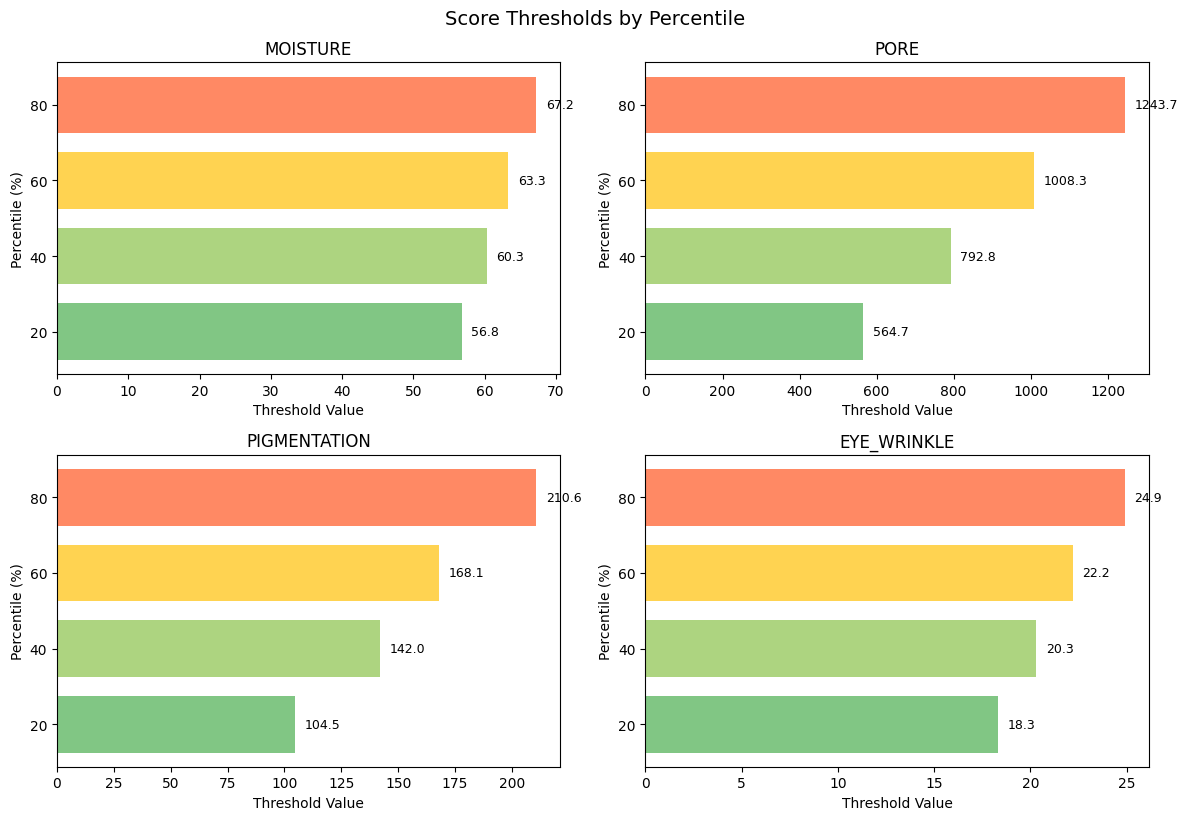

In [49]:
# Threshold visualization
thresholds = {
    "moisture": [56.8, 60.3, 63.3, 67.2],
    "pore": [564.7, 792.8, 1008.3, 1243.7],
    "pigmentation": [104.5, 142.0, 168.1, 210.6],
    "eye_wrinkle": [18.3, 20.3, 22.2, 24.9]
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (name, vals) in enumerate(thresholds.items()):
    ax = axes[idx]
    positions = [20, 40, 60, 80]
    bars = ax.barh(positions, vals, height=15, alpha=0.7, color=['#4CAF50', '#8BC34A', '#FFC107', '#FF5722'])
    ax.set_xlabel('Threshold Value')
    ax.set_ylabel('Percentile (%)')
    ax.set_title(name.upper())
    ax.set_yticks(positions)
    
    for i, v in enumerate(vals):
        ax.text(v + max(vals)*0.02, positions[i], f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Score Thresholds by Percentile', y=1.02, fontsize=14)
plt.show()

---
## 6. 성능 벤치마크

In [50]:
benchmark_info = """
### Inference Performance (CPU)

| Engine | Avg Latency |
|:---|:---:|
| PyTorch | ~78 ms |
| ONNX Runtime | ~108 ms |

### Docker Image Size

| Build Type | Size |
|:---|:---:|
| PyTorch | ~1.7 GB |
| ONNX | ~300 MB |

**Optimization Effect**: ~90% reduction (~1.4 GB saved)
"""
display(Markdown(benchmark_info))


### Inference Performance (CPU)

| Engine | Avg Latency |
|:---|:---:|
| PyTorch | ~78 ms |
| ONNX Runtime | ~108 ms |

### Docker Image Size

| Build Type | Size |
|:---|:---:|
| PyTorch | ~1.7 GB |
| ONNX | ~300 MB |

**Optimization Effect**: ~90% reduction (~1.4 GB saved)


In [51]:
# ONNX inference test
try:
    import onnxruntime as ort
    
    onnx_path = PROJECT_ROOT / "checkpoint" / "regression" / "1st_robust" / "save_model" / "moisture" / "model.onnx"
    
    if onnx_path.exists():
        sess = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])
        dummy = np.random.randn(1, 3, 224, 224).astype(np.float32)
        
        import time
        times = []
        for _ in range(10):
            start = time.time()
            _ = sess.run(None, {sess.get_inputs()[0].name: dummy})
            times.append((time.time() - start) * 1000)
        
        print(f"ONNX Inference Test: SUCCESS")
        print(f"Average Latency: {np.mean(times):.2f} ms")
    else:
        print("ONNX model file not found.")
        
except ImportError:
    print("onnxruntime is not installed.")

ONNX Inference Test: SUCCESS
Average Latency: 125.35 ms


---
## 7. PyTorch vs ONNX 비교

PyTorch 모델과 ONNX 모델의 추론 결과가 동일한지 확인합니다.

In [52]:
# PyTorch vs ONNX Output Comparison
try:
    import torch
    import timm
    import onnxruntime as ort
    
    model_name = 'moisture'
    onnx_path = PROJECT_ROOT / "checkpoint" / "regression" / "1st_robust" / "save_model" / model_name / "model.onnx"
    pth_path = PROJECT_ROOT / "checkpoint" / "regression" / "1st_robust" / "save_model" / model_name / "state_dict.bin"
    
    if onnx_path.exists() and pth_path.exists():
        # Load PyTorch model
        pt_model = timm.create_model('coatnet_2_rw_224', pretrained=False, num_classes=1)
        
        # Load checkpoint (key is 'model_state', not 'model')
        checkpoint = torch.load(pth_path, map_location='cpu', weights_only=False)
        pt_model.load_state_dict(checkpoint['model_state'])
        pt_model.eval()
        
        # Load ONNX model
        onnx_sess = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])
        
        # Create test input
        np.random.seed(42)
        test_input = np.random.randn(1, 3, 224, 224).astype(np.float32)
        
        # PyTorch inference
        with torch.no_grad():
            pt_output = pt_model(torch.from_numpy(test_input)).numpy()
        
        # ONNX inference
        onnx_output = onnx_sess.run(None, {onnx_sess.get_inputs()[0].name: test_input})[0]
        
        # Compare
        diff = np.abs(pt_output - onnx_output)
        max_diff = np.max(diff)
        mean_diff = np.mean(diff)
        
        print("=" * 50)
        print(f"PyTorch vs ONNX Comparison ({model_name})")
        print("=" * 50)
        print(f"PyTorch output: {pt_output.flatten()[0]:.6f}")
        print(f"ONNX output:    {onnx_output.flatten()[0]:.6f}")
        print(f"Max difference: {max_diff:.10f}")
        print(f"Mean difference: {mean_diff:.10f}")
        print("=" * 50)
        print(f"RESULT: {'EQUIVALENT (diff < 1e-5)' if max_diff < 1e-5 else 'DIFFERENT'}")
    else:
        print("Model files not found.")
        
except ImportError as e:
    print(f"Required package not installed: {e}")

PyTorch vs ONNX Comparison (moisture)
PyTorch output: 0.543697
ONNX output:    0.543696
Max difference: 0.0000016689
Mean difference: 0.0000016689
RESULT: EQUIVALENT (diff < 1e-5)


In [53]:
# Compare all regression models
try:
    import torch
    import timm
    import onnxruntime as ort
    
    models = ['moisture', 'pore', 'pigmentation', 'wrinkle_Ra']
    
    np.random.seed(42)
    test_input = np.random.randn(1, 3, 224, 224).astype(np.float32)
    
    print("All Regression Models Comparison")
    print("=" * 70)
    print(f"{'Model':<15} {'PyTorch':<15} {'ONNX':<15} {'Max Diff':<15} {'Status'}")
    print("-" * 70)
    
    for model_name in models:
        onnx_path = PROJECT_ROOT / "checkpoint" / "regression" / "1st_robust" / "save_model" / model_name / "model.onnx"
        pth_path = PROJECT_ROOT / "checkpoint" / "regression" / "1st_robust" / "save_model" / model_name / "state_dict.bin"
        
        if onnx_path.exists() and pth_path.exists():
            pt_model = timm.create_model('coatnet_2_rw_224', pretrained=False, num_classes=1)
            checkpoint = torch.load(pth_path, map_location='cpu', weights_only=False)
            pt_model.load_state_dict(checkpoint['model_state'])
            pt_model.eval()
            
            onnx_sess = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])
            
            with torch.no_grad():
                pt_out = pt_model(torch.from_numpy(test_input)).numpy().flatten()[0]
            onnx_out = onnx_sess.run(None, {onnx_sess.get_inputs()[0].name: test_input})[0].flatten()[0]
            
            diff = abs(pt_out - onnx_out)
            status = 'OK' if diff < 1e-5 else 'DIFF'
            
            print(f"{model_name:<15} {pt_out:<15.6f} {onnx_out:<15.6f} {diff:<15.10f} {status}")
    
    print("=" * 70)
    print("Conclusion: PyTorch and ONNX outputs are numerically equivalent.")
    
except ImportError as e:
    print(f"Required package not installed: {e}")

All Regression Models Comparison
Model           PyTorch         ONNX            Max Diff        Status
----------------------------------------------------------------------
moisture        0.543697        0.543696        0.0000016689    OK
pore            0.598774        0.598773        0.0000011921    OK
pigmentation    0.585021        0.585019        0.0000015497    OK
wrinkle_Ra      0.407950        0.407949        0.0000009537    OK
Conclusion: PyTorch and ONNX outputs are numerically equivalent.


---
## 요약

**ONNX로 최적화된 CoAtNet 기반 피부 분석 AI**

- **6개 모델**: 수분, 모공, 색소침착, 눈가 주름, 주름(분류), 처짐
- **다각도 분석**: 정면, 좌측 30도, 우측 30도
- **최적화 효과**: Docker 이미지 90% 축소 (1.7GB → 300MB)
- **점수 체계**: 백분위 기반 0~100점, 5개 등급
- **정확도**: PyTorch와 ONNX 출력값 수치적 동일 (오차 < 1e-5)